# Example 04 — MPC with Certificate-based Terminal Set

**System**: Planar rocket / quadrotor  
$\dot{p}_x = v_x,\; \dot{p}_z = v_z,\; \dot{\theta} = \omega,\; \dot{v}_x = \frac{\sin\theta}{m}F,\; \dot{v}_z = \frac{\cos\theta}{m}F - g,\; \dot{\omega} = -\frac{M}{I}$

**Output**: tip position $y = h(x) = [p_x - L\sin\theta,\; p_z - L\cos\theta]$

**Goal**: Drive $y$ into the flat ellipse target set while staying inside the squircle safe set.

**MPC formulation**:  
Minimise output-tracking cost subject to dynamics, control bounds, safe-set path constraints, and a **certificate-based terminal constraint** $V(x_N) \ge 0$.  
The terminal constraint ensures that once MPC reaches the certified region the reach-avoid task is guaranteed to be completable.


In [957]:
# ── Imports & load computed certificate / controller ─────────────────────────
import sympy as sp
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from functional import BetterColor

from sop_bounded_control_ex4_result_20260315_110901 import (
    u_opt,
    certificate_opt,
    k1_opt,
)

u_opt = sp.Matrix(u_opt)
k1_opt = sp.Matrix(k1_opt)

print("Symbols in u_opt[0] (F):", u_opt[0].free_symbols)
print("Symbols in u_opt[1] (M):", u_opt[1].free_symbols)
print("Symbols in certificate_opt:", certificate_opt.free_symbols)
print("Symbols in k1_opt:", k1_opt.free_symbols)
print(f"\nCasADi version: {ca.__version__}")

Symbols in u_opt[0] (F): {th, vx, pz, vz, om, px}
Symbols in u_opt[1] (M): {th, vx, pz, vz, om, px}
Symbols in certificate_opt: {th, pz, vz, om, px, vx}
Symbols in k1_opt: {y1, y2}

CasADi version: 3.7.2


In [958]:
# ── System & set definitions (same as example_04_no_mpc) ─────────────────────
px, pz, th, vx, vz, om = sp.symbols("px pz th vx vz om")
y1, y2 = sp.symbols("y1 y2")
state_vars = [px, pz, th, vx, vz, om]

# Physical parameters
g_grav = 9.81
m_mass = 1.0
I_inertia = 0.1
L = 0.1  # nozzle arm length [m]

# Output map  y = h(x)
hx = sp.Matrix([px - L * sp.sin(th), pz - L * sp.cos(th)])

# Target set: flat ellipse in y-space  (phi(y) <= 0  inside target)
x_target, z_target = 0.0, 1.0
r_y1 = 0.3
r_y2 = 0.05
target_set_y = (y1 - x_target) ** 2 / r_y1**2 + (y2 - z_target) ** 2 / r_y2**2 - 1

# Safe set: squircle in y-space  (psi(y) >= 0  inside safe region)
W_x = 2.0
W_z = 2.0
x_c = 0.0
z_c = 1.0
C_coeff = (W_x / W_z) ** 4
safe_set_y = W_x**4 - (y1 - x_c) ** 4 - C_coeff * (y2 - z_c) ** 4

# Lift to state space
safe_set_x = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

# Control bounds
F_lb, F_ub = -80.0, 350.0  # thrust  [N]
M_lb, M_ub = -50.0, 50.0  # moment  [N·m]

# Numpy-callable lambdas
certificate_func = sp.lambdify(state_vars, certificate_opt, "numpy")
safe_set_x_func = sp.lambdify(state_vars, safe_set_x, "numpy")
target_set_x_func = sp.lambdify(state_vars, target_set_x, "numpy")
safe_set_y_func = sp.lambdify([y1, y2], safe_set_y, "numpy")
target_set_y_func = sp.lambdify([y1, y2], target_set_y, "numpy")
k1_y_func = sp.lambdify([y1, y2], k1_opt, "numpy")
hx_func = sp.lambdify(state_vars, hx, "numpy")

print("h(x):", hx.T)
print("safe_set   (y):", safe_set_y)
print("target_set (y):", target_set_y)

h(x): Matrix([[px - 0.1*sin(th), pz - 0.1*cos(th)]])
safe_set   (y): -y1**4 - 1.0*(y2 - 1.0)**4 + 16.0
target_set (y): 11.1111111111111*y1**2 + 400.0*(y2 - 1.0)**2 - 1


In [959]:
# ── Sample initial states OUTSIDE the certificate region ─────────────────────
# Target states where V(x0) is just below 0 (cert depth >= -8):
#   • position near the safe-set boundary  →  y1^4 + (y2-1)^4 close to 16
#   • modest velocities so the MPC can easily restore the cert condition
N_samples = 50000
np.random.seed(42)

#                  px    pz     th           vx    vz    om
lower_bound = np.array([-2.0, 0.0, -np.pi / 6, -0.5, -0.5, -0.1])
upper_bound = np.array([2.0, 4.0, np.pi / 6, 0.5, 0.5, 0.1])

x_samples = np.random.rand(6, N_samples) * (upper_bound - lower_bound).reshape(
    -1, 1
) + lower_bound.reshape(-1, 1)

np.seterr(over="ignore", invalid="ignore")

cert_vals = np.atleast_1d(np.squeeze(certificate_func(*x_samples)))
safe_vals = np.atleast_1d(np.squeeze(safe_set_x_func(*x_samples)))
target_vals = np.atleast_1d(np.squeeze(target_set_x_func(*x_samples)))

# Keep states that are just outside the cert region (V in [-8, 0))
# so the MPC terminal constraint V(x_N)>=0 is reachable in a short horizon.
valid_idx = np.where(
    (cert_vals >= -150) & (cert_vals < 0) & (safe_vals >= 0) & (target_vals > 0)
)[0]

x_valid_mpc = x_samples[:, valid_idx]
print(f"Valid MPC initial states: {len(valid_idx)} / {N_samples}")
print(
    f"  cert range: [{cert_vals[valid_idx].min():.2f}, {cert_vals[valid_idx].max():.2f}]"
)

names = ["px", "pz", "th", "vx", "vz", "om"]
for i, n in enumerate(names):
    print(f"  {n}: [{x_valid_mpc[i].min():.3f}, {x_valid_mpc[i].max():.3f}]")

Valid MPC initial states: 11304 / 50000
  cert range: [-149.96, -0.00]
  px: [-1.782, 1.999]
  pz: [0.000, 2.132]
  th: [-0.524, 0.524]
  vx: [-0.500, 0.500]
  vz: [-0.500, 0.500]
  om: [-0.100, 0.100]


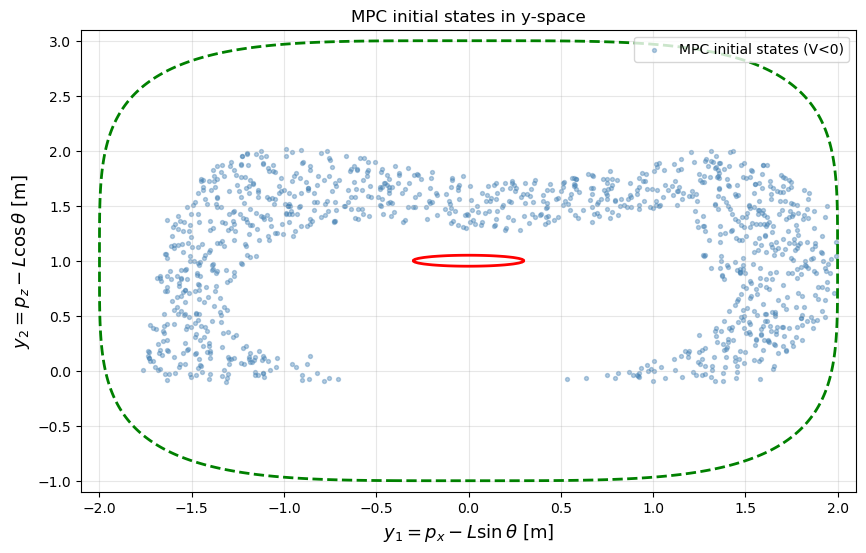

In [960]:
# ── Visualise MPC initial states in y-space ───────────────────────────────────
y_valid_mpc = hx_func(*x_valid_mpc).reshape(2, -1)

n_grid = 500
y1_g = np.linspace(-2.1, 2.1, n_grid)
y2_g = np.linspace(-1.1, 3.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe = safe_set_y_func(Y1, Y2)
Z_target = target_set_y_func(Y1, Y2)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.contour(Y1, Y2, Z_safe, levels=[0], colors="g", linestyles="--", linewidths=2)
ax.contour(Y1, Y2, Z_target, levels=[0], colors="r", linestyles="-", linewidths=2)
ax.scatter(
    y_valid_mpc[0, ::10],
    y_valid_mpc[1, ::10],
    color="steelblue",
    s=8,
    alpha=0.4,
    label="MPC initial states (V<0)",
)
ax.set_xlabel("$y_1 = p_x - L\\sin\\theta$ [m]", fontsize=13)
ax.set_ylabel("$y_2 = p_z - L\\cos\\theta$ [m]", fontsize=13)
ax.set_title("MPC initial states in y-space", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()

In [961]:
# ── Sympy -> CasADi converter (polynomials + sin/cos) ────────────────────────
def sympy2casadi(expr, sym_map):
    """Recursively convert a sympy expression to a CasADi SX expression."""
    if isinstance(
        expr,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
        ),
    ):
        return float(expr)
    elif isinstance(expr, sp.Symbol):
        return sym_map[expr]
    elif isinstance(expr, sp.Add):
        return sum(sympy2casadi(a, sym_map) for a in expr.args)
    elif isinstance(expr, sp.Mul):
        result = 1.0
        for a in expr.args:
            result = result * sympy2casadi(a, sym_map)
        return result
    elif isinstance(expr, sp.Pow):
        base = sympy2casadi(expr.args[0], sym_map)
        exp = sympy2casadi(expr.args[1], sym_map)
        return base**exp
    elif isinstance(expr, sp.sin):
        return ca.sin(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.cos):
        return ca.cos(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.Number):
        return float(expr)
    else:
        raise ValueError(f"Unsupported sympy type: {type(expr)}  --  {expr}")


# CasADi scalar symbols matching state_vars order
ca_px = ca.SX.sym("px")
ca_pz = ca.SX.sym("pz")
ca_th = ca.SX.sym("th")
ca_vx = ca.SX.sym("vx")
ca_vz = ca.SX.sym("vz")
ca_om = ca.SX.sym("om")

sym_map_6 = {px: ca_px, pz: ca_pz, th: ca_th, vx: ca_vx, vz: ca_vz, om: ca_om}

# Certificate V(x)
cert_ca_expr = sympy2casadi(certificate_opt, sym_map_6)
cert_ca_func = ca.Function(
    "cert",
    [ca_px, ca_pz, ca_th, ca_vx, ca_vz, ca_om],
    [cert_ca_expr],
)

# Safe set psi(x) >= 0
safe_ca_expr = sympy2casadi(safe_set_x, sym_map_6)
safe_ca_func = ca.Function(
    "safe",
    [ca_px, ca_pz, ca_th, ca_vx, ca_vz, ca_om],
    [safe_ca_expr],
)

# Sanity checks
test_x = np.array([0.5, 1.5, 0.1, 0.2, -0.3, 0.05])
v_sp = float(certificate_opt.subs(dict(zip(state_vars, test_x))))
v_ca = float(cert_ca_func(*test_x))
print(f"Certificate:  sympy = {v_sp:.8f},  casadi = {v_ca:.8f}")
assert abs(v_sp - v_ca) < 1e-5, "Certificate conversion mismatch!"

s_sp = float(safe_set_x.subs(dict(zip(state_vars, test_x))))
s_ca = float(safe_ca_func(*test_x))
print(f"Safe set:     sympy = {s_sp:.8f},  casadi = {s_ca:.8f}")
assert abs(s_sp - s_ca) < 1e-5, "Safe set conversion mismatch!"

print("All conversions verified OK.")

Certificate:  sympy = -12.51052349,  casadi = -12.51052349
Safe set:     sympy = 15.91661602,  casadi = 15.91661602
All conversions verified OK.


In [962]:
# ── MPC problem formulation ───────────────────────────────────────────────────
nx_s = 6  # state dim:   [px, pz, th, vx, vz, om]
nu_s = 2  # control dim: [F, M]
dt = 0.005  # MPC discretisation step (s)
N = 20  # prediction horizon → 1.0 s look-ahead
#
# Parameter rationale:
#   dt=0.05 / N=20 : 1 s horizon is sufficient because target states are
#                    only ~0.1-0.2 m from the cert boundary (V in [-8,0)).
#   Q_y light       : gives IPOPT more room to satisfy the cert terminal
#                    constraint without fighting a heavy stage cost.
#   Qf_y stronger   : steers the terminal state toward the output target.
#   R_u very small  : the rocket needs large F (~10 N) just to hover, so
#                    penalising thrust too heavily destroys feasibility.
#   tol=1e-4        : relaxed solver tolerance for speed; the cert constraint
#                    has O(1) scale so 1e-4 accuracy is more than enough.

y_target_val = np.array([x_target, z_target])  # [0.0, 1.0]
Q_y = np.diag([5.0, 5.0])  # stage output penalty  (light)
Qf_y = np.diag([80.0, 80.0])  # terminal output penalty (stronger)
R_u = np.diag([1e-3, 1e-2])  # control penalty (minimal — F is large scale)

# ── CasADi symbolic system ───────────────────────────────────────────────────
x_ca_var = ca.SX.sym("x", nx_s)
u_ca_var = ca.SX.sym("u", nu_s)

xdot_ca = ca.vertcat(
    x_ca_var[3],
    x_ca_var[4],
    x_ca_var[5],
    ca.sin(x_ca_var[2]) / m_mass * u_ca_var[0],
    ca.cos(x_ca_var[2]) / m_mass * u_ca_var[0] - g_grav,
    -u_ca_var[1] / I_inertia,
)
f_ca = ca.Function("f", [x_ca_var, u_ca_var], [xdot_ca])

# RK4 integrator (one step of length dt)
k1 = f_ca(x_ca_var, u_ca_var)
k2 = f_ca(x_ca_var + dt / 2 * k1, u_ca_var)
k3 = f_ca(x_ca_var + dt / 2 * k2, u_ca_var)
k4 = f_ca(x_ca_var + dt * k3, u_ca_var)
x_next_expr = x_ca_var + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
F_disc = ca.Function("F_disc", [x_ca_var, u_ca_var], [x_next_expr])


# Output map h(x)
def h_ca(xv):
    return ca.vertcat(
        xv[0] - L * ca.sin(xv[2]),
        xv[1] - L * ca.cos(xv[2]),
    )


# Wrappers to call scalar-input CasADi functions from a vector
def cert_vec(xv):
    return cert_ca_func(xv[0], xv[1], xv[2], xv[3], xv[4], xv[5])


def safe_vec(xv):
    return safe_ca_func(xv[0], xv[1], xv[2], xv[3], xv[4], xv[5])


# ── Opti NLP ─────────────────────────────────────────────────────────────────
opti = ca.Opti()

X_var = opti.variable(nx_s, N + 1)
U_var = opti.variable(nu_s, N)
x0_param = opti.parameter(nx_s)

# Stage + terminal cost
cost = 0
for k in range(N):
    dy = h_ca(X_var[:, k]) - y_target_val
    cost += dy.T @ Q_y @ dy
    cost += U_var[:, k].T @ R_u @ U_var[:, k]

dy_N = h_ca(X_var[:, N]) - y_target_val
cost += dy_N.T @ Qf_y @ dy_N
opti.minimize(cost)

# Constraints
opti.subject_to(X_var[:, 0] == x0_param)
for k in range(N):
    opti.subject_to(X_var[:, k + 1] == F_disc(X_var[:, k], U_var[:, k]))

# Asymmetric control bounds
opti.subject_to(opti.bounded(F_lb, U_var[0, :], F_ub))
opti.subject_to(opti.bounded(M_lb, U_var[1, :], M_ub))

# Safe-set path constraint at every node
for k in range(N + 1):
    opti.subject_to(safe_vec(X_var[:, k]) >= 0)

# Terminal constraint: V(x_N) >= 0  (certificate super-level set)
opti.subject_to(cert_vec(X_var[:, N]) >= 0)

# ── Solver ────────────────────────────────────────────────────────────────────
opts = {
    "ipopt.print_level": 0,
    "print_time": False,
    "ipopt.max_iter": 3000,
    "ipopt.tol": 1e-4,  # relaxed: cert scale ~O(1), 1e-4 is sufficient
    "ipopt.acceptable_tol": 1e-3,
}
opti.solver("ipopt", opts)

print("MPC NLP built successfully.")
print(f"  nx={nx_s}, nu={nu_s}, N={N}, dt={dt} s  (horizon = {N * dt:.2f} s)")
print(f"  Control bounds:  F in [{F_lb}, {F_ub}] N,  M in [{M_lb}, {M_ub}] N*m")
print(f"  Q_y  = diag{np.diag(Q_y).tolist()}")
print(f"  Qf_y = diag{np.diag(Qf_y).tolist()}")
print(f"  R_u  = diag{np.diag(R_u).tolist()}")
print(f"  Terminal set: V(x_N) >= 0")

MPC NLP built successfully.
  nx=6, nu=2, N=20, dt=0.005 s  (horizon = 0.10 s)
  Control bounds:  F in [-80.0, 350.0] N,  M in [-50.0, 50.0] N*m
  Q_y  = diag[5.0, 5.0]
  Qf_y = diag[80.0, 80.0]
  R_u  = diag[0.001, 0.01]
  Terminal set: V(x_N) >= 0


In [963]:
# ── Filter MPC-feasible initial states ───────────────────────────────────────
# Warm-start: hold current state constant, thrust = hover, zero moment.
# Because valid samples already have V in [-8, 0), a single RK4-horizon
# of the hover trajectory is often nearly feasible → IPOPT converges fast.
max_feasible = 50
F_hover = m_mass * g_grav  # ~9.81 N

feasible_idx = []

for i in range(x_valid_mpc.shape[1]):
    x0 = x_valid_mpc[:, i].copy()

    opti.set_value(x0_param, x0)
    # Warm-start: constant-state trajectory + hover thrust
    opti.set_initial(X_var, np.tile(x0.reshape(-1, 1), (1, N + 1)))
    opti.set_initial(U_var, np.tile([F_hover, 0.0], (N, 1)).T)

    try:
        opti.solve()
        cert_x0 = float(certificate_func(*x0))
        print(f"  Feasible {i:4d}  V(x0)={cert_x0:+.3f}  x0={x0.round(3)}")
        feasible_idx.append(i)
    except Exception:
        pass

    if len(feasible_idx) >= max_feasible:
        print(f"\nReached {max_feasible} feasible samples -- stopping.")
        break

x_mpc_init = x_valid_mpc[:, feasible_idx]
print(f"\nTotal feasible MPC initial states: {len(feasible_idx)}")

  Feasible    0  V(x0)=-79.374  x0=[-1.376  1.675 -0.141  0.337 -0.297 -0.013]
  Feasible    1  V(x0)=-14.356  x0=[ 0.404  1.494 -0.167  0.002  0.078 -0.084]
  Feasible    2  V(x0)=-4.605  x0=[ 0.447  1.425  0.289 -0.38   0.246 -0.099]
  Feasible    3  V(x0)=-9.042  x0=[-1.201  1.282 -0.382 -0.46   0.454  0.074]
  Feasible    4  V(x0)=-9.247  x0=[-1.318  1.097  0.045  0.247 -0.092  0.003]
  Feasible    5  V(x0)=-6.618  x0=[ 1.234  1.582 -0.429 -0.04   0.29  -0.084]
  Feasible    6  V(x0)=-82.572  x0=[-0.239  1.793 -0.098 -0.46  -0.063 -0.051]
  Feasible    7  V(x0)=-92.797  x0=[-0.965  1.974 -0.293  0.25   0.227  0.032]
  Feasible    8  V(x0)=-68.882  x0=[ 0.08   1.683 -0.475 -0.212 -0.     0.041]
  Feasible   10  V(x0)=-4.986  x0=[ 1.758  1.032 -0.457 -0.097  0.411  0.007]
  Feasible   11  V(x0)=-5.376  x0=[-0.699  1.526 -0.463  0.123  0.113 -0.071]
  Feasible   12  V(x0)=-1.469  x0=[-1.205  0.33   0.519  0.043  0.256  0.094]
  Feasible   13  V(x0)=-13.229  x0=[ 1.262  0.17  -0.394  0

In [964]:
# ── Closed-loop MPC simulation ────────────────────────────────────────────────
# Pure MPC: solve at every step until the target is reached.
# Warm-start strategy: shift the previous optimal solution by one step
# (standard receding-horizon warm-start) for fast IPOPT convergence.

max_steps_per_traj = 300  # max MPC steps per trajectory  (20 s at dt=0.05)

np.seterr(over="ignore", invalid="ignore")


def rk4_step(x_cur, u_vec, dt_step):
    """RK4 step with constant control u_vec = [F, M]."""

    def dyn(xv):
        F_val, M_val = u_vec
        return np.array(
            [
                xv[3],
                xv[4],
                xv[5],
                np.sin(xv[2]) / m_mass * F_val,
                np.cos(xv[2]) / m_mass * F_val - g_grav,
                -M_val / I_inertia,
            ]
        )

    k1 = dyn(x_cur)
    k2 = dyn(x_cur + 0.5 * dt_step * k1)
    k3 = dyn(x_cur + 0.5 * dt_step * k2)
    k4 = dyn(x_cur + dt_step * k3)
    return x_cur + (dt_step / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


traj_x_mpc = []
traj_u_mpc = []

for i in range(x_mpc_init.shape[1]):
    x0 = x_mpc_init[:, i].copy()
    print(
        f"Trajectory {i + 1}  V(x0)={float(certificate_func(*x0)):+.3f}"
        f"  x0={x0.round(3)} ...",
        end="  ",
    )

    x_cur = x0.copy()
    this_x = [x_cur.copy()]
    this_u = []
    failed = False
    prev_sol = None

    for step in range(max_steps_per_traj):
        target_val = float(np.squeeze(target_set_x_func(*x_cur)))
        if target_val <= 0:
            print(f"reached target at step {step}  (t = {step * dt:.2f} s)")
            break

        opti.set_value(x0_param, x_cur)

        # Warm-start: shift previous solution by one step (receding horizon)
        if prev_sol is not None:
            X_ws = np.hstack([prev_sol["X"][:, 1:], prev_sol["X"][:, -1:]])
            U_ws = np.hstack([prev_sol["U"][:, 1:], prev_sol["U"][:, -1:]])
            opti.set_initial(X_var, X_ws)
            opti.set_initial(U_var, U_ws)
        else:
            opti.set_initial(X_var, np.tile(x_cur.reshape(-1, 1), (1, N + 1)))
            opti.set_initial(U_var, np.tile([F_hover, 0.0], (N, 1)).T)

        try:
            sol = opti.solve()
            u_mpc = sol.value(U_var[:, 0])
            prev_sol = {"X": sol.value(X_var), "U": sol.value(U_var)}
        except Exception as e:
            print(f"\n  [step {step}] solver failed: {e}")
            failed = True
            break

        x_next = rk4_step(x_cur, u_mpc, dt)
        if not np.all(np.isfinite(x_next)):
            print(f"\n  [step {step}] state diverged")
            failed = True
            break

        this_x.append(x_next.copy())
        this_u.append(u_mpc.copy())
        x_cur = x_next
    else:
        print(f"max steps ({max_steps_per_traj}) reached")

    if not failed:
        traj_x_mpc.append(np.array(this_x))
        traj_u_mpc.append(np.array(this_u))

print(f"\nDone. {len(traj_x_mpc)} trajectories simulated.")

Trajectory 1  V(x0)=-79.374  x0=[-1.376  1.675 -0.141  0.337 -0.297 -0.013] ...  reached target at step 159  (t = 0.80 s)
Trajectory 2  V(x0)=-14.356  x0=[ 0.404  1.494 -0.167  0.002  0.078 -0.084] ...  max steps (300) reached
Trajectory 3  V(x0)=-4.605  x0=[ 0.447  1.425  0.289 -0.38   0.246 -0.099] ...  reached target at step 37  (t = 0.18 s)
Trajectory 4  V(x0)=-9.042  x0=[-1.201  1.282 -0.382 -0.46   0.454  0.074] ...  reached target at step 161  (t = 0.81 s)
Trajectory 5  V(x0)=-9.247  x0=[-1.318  1.097  0.045  0.247 -0.092  0.003] ...  reached target at step 162  (t = 0.81 s)
Trajectory 6  V(x0)=-6.618  x0=[ 1.234  1.582 -0.429 -0.04   0.29  -0.084] ...  max steps (300) reached
Trajectory 7  V(x0)=-82.572  x0=[-0.239  1.793 -0.098 -0.46  -0.063 -0.051] ...  reached target at step 42  (t = 0.21 s)
Trajectory 8  V(x0)=-92.797  x0=[-0.965  1.974 -0.293  0.25   0.227  0.032] ...  reached target at step 259  (t = 1.29 s)
Trajectory 9  V(x0)=-68.882  x0=[ 0.08   1.683 -0.475 -0.212 -0.

In [965]:
# fiter out too short & stop at max steps
traj_x_mpc_filt = []
traj_u_mpc_filt = []

min_steps = 180
for x_traj, u_traj in zip(traj_x_mpc, traj_u_mpc):
    if len(x_traj) >= min_steps and len(x_traj) < max_steps_per_traj:
        traj_x_mpc_filt.append(x_traj[:max_steps_per_traj])
        traj_u_mpc_filt.append(u_traj[:max_steps_per_traj])

# update traj_x_mpc, traj_u_mpc to the filtered versions
# traj_x_mpc = traj_x_mpc_filt
# traj_u_mpc = traj_u_mpc_filt

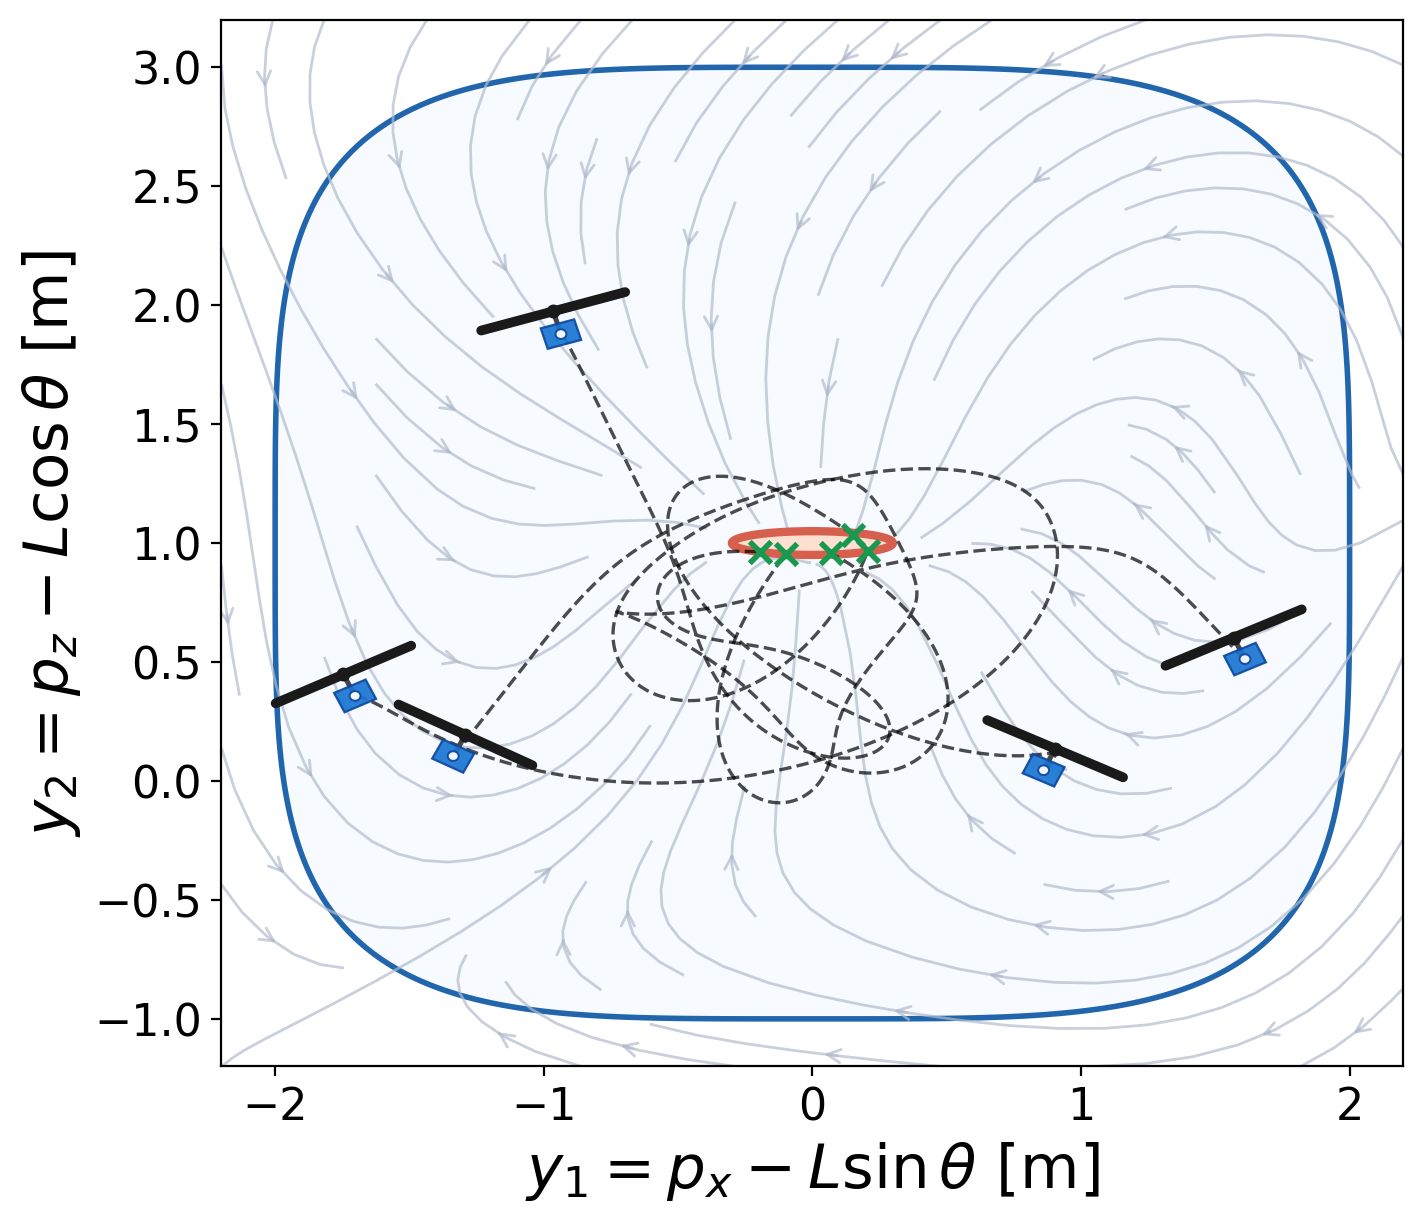

In [977]:
# ── Visualise closed-loop tip trajectories in y-space ────────────────────────
from matplotlib.patches import Circle, Polygon as MplPolygon


# ── Helper: draw one planar quadrotor at a given start state ─────────────────
def draw_quadrotor_at(
    ax, y1_tip, y2_tip, th_val, body_half=0.28, rotor_r=0.09, cam_w=0.13, cam_h=0.09
):
    """
    Overlay the planar quadrotor body on a y-space plot at the tip position.

    Geometry (all in y-space, which shares the same metric axes as (px,pz)):
      tip  = (y1_tip, y2_tip)        -- nozzle / camera mount = h(x)
      com  = tip + L*(sin theta, cos theta)  -- centre of mass  (L=1 m above tip)
      bar  = COM +/- body_half * perp  -- body bar perpendicular to arm
      rotors at each bar end
      camera: filled rect centred at tip, rotated by theta, with a lens dot
    """
    s, c = np.sin(th_val), np.cos(th_val)
    tip = np.array([y1_tip, y2_tip])
    com = tip + L * np.array([s, c])  # COM is L m "above" the tip
    perp = np.array([c, -s])  # perpendicular to the arm axis

    # ── Camera arm ────────────────────────────────────────────────────────
    ax.plot(
        [tip[0], com[0]],
        [tip[1], com[1]],
        color="#444444",
        lw=1.8,
        solid_capstyle="round",
        zorder=24,
    )

    # ── Camera body at tip (rotated rectangle) ────────────────────────────
    hw, hh = cam_w / 2, cam_h / 2
    # rectangle corners in body-frame (arm axis = local y, perp = local x)
    body_axis = np.array([s, c])
    corners = (
        np.array([[-hw, hh], [hw, hh], [hw, -hh], [-hw, -hh]])
        @ np.array([[perp[0], body_axis[0]], [perp[1], body_axis[1]]]).T
    ) + tip
    ax.add_patch(
        MplPolygon(
            corners,
            closed=True,
            facecolor="#1976D2",
            edgecolor="#0D47A1",
            lw=0.8,
            zorder=26,
            alpha=0.92,
        )
    )
    # Lens: white circle on camera face
    ax.add_patch(
        Circle(
            tip,
            hh * 0.45,
            facecolor="white",
            edgecolor="#0D47A1",
            lw=0.7,
            zorder=27,
            alpha=0.95,
        )
    )

    # ── Body bar ──────────────────────────────────────────────────────────
    bar_l = com - body_half * perp
    bar_r = com + body_half * perp
    ax.plot(
        [bar_l[0], bar_r[0]],
        [bar_l[1], bar_r[1]],
        color="#1a1a1a",
        lw=3.5,
        solid_capstyle="round",
        zorder=25,
    )

    # ── COM dot ───────────────────────────────────────────────────────────
    ax.scatter(com[0], com[1], s=16, c="#1a1a1a", zorder=28)


def build_k1_vector_field(y1_grid, y2_grid):
    """Evaluate k1(y) and return 2D vector components U,V on the mesh grid."""
    k1_eval = np.asarray(k1_y_func(y1_grid, y2_grid), dtype=float)
    k1_eval = np.squeeze(k1_eval)

    # Typical matrix-valued lambdify output after squeeze: (2, ny, nx).
    if k1_eval.ndim == 3 and k1_eval.shape[0] >= 2:
        U = k1_eval[0]
        V = k1_eval[1]
        return U, V

    # Fallback: scalar field interpreted as x-direction component only.
    if k1_eval.ndim == 2 and k1_eval.shape == y1_grid.shape:
        U = k1_eval
        V = np.zeros_like(U)
        return U, V

    # Constant 2-vector fallback.
    if k1_eval.ndim == 1 and k1_eval.size == 2:
        U = np.full_like(y1_grid, float(k1_eval[0]))
        V = np.full_like(y2_grid, float(k1_eval[1]))
        return U, V

    raise ValueError(f"Unexpected k1_y_func output shape: {k1_eval.shape}")


# ── Background: sets ──────────────────────────────────────────────────────────
n_grid = 800
y1_g = np.linspace(-2.2, 2.2, n_grid)
y2_g = np.linspace(-1.2, 3.2, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe_y = safe_set_y_func(Y1, Y2)
Z_target_y = target_set_y_func(Y1, Y2)
U_k1, V_k1 = build_k1_vector_field(Y1, Y2)
U_k1 = np.nan_to_num(U_k1, nan=0.0, posinf=0.0, neginf=0.0)
V_k1 = np.nan_to_num(V_k1, nan=0.0, posinf=0.0, neginf=0.0)

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(700 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)

# Safe region
ax.contourf(
    Y1, Y2, Z_safe_y, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(Y1, Y2, Z_safe_y, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
# Target region
ax.contourf(
    Y1, Y2, Z_target_y, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
)
ax.contour(Y1, Y2, Z_target_y, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)

# k1(y) stream field (without colorbar / quiver)
speed = np.hypot(U_k1, V_k1)
finite_speed = speed[np.isfinite(speed)]
s_ref = np.percentile(finite_speed, 95) if finite_speed.size > 0 else 1.0
s_ref = max(float(s_ref), 1e-6)
lw_stream = 0.6 + 1.8 * np.clip(speed / s_ref, 0.0, 1.0)

ax.streamplot(
    y1_g,
    y2_g,
    U_k1,
    V_k1,
    density=0.8,
    # color="#2C7FB8",
    color=BetterColor.gray0(0.7),
    # linewidth=lw_stream,
    # arrowsize=1.0,
    # minlength=0.15,
    # maxlength=4.0,
    # broken_streamlines=True,
    # zorder=6,
    linewidth=1,
    arrowstyle="->",
    arrowsize=1.2,
)

# ── Trajectories + quadrotor pose at start ───────────────────────────────────
for tx in traj_x_mpc_filt:
    ty = hx_func(*tx.T).reshape(2, -1).T  # (T+1, 2)  tip positions in y-space

    # Tip trajectory
    ax.plot(
        ty[:, 0], ty[:, 1], color="black", lw=1.2, alpha=0.7, zorder=10, linestyle="--"
    )

    # End-point marker
    ax.scatter(
        ty[-1, 0],
        ty[-1, 1],
        s=60,
        color=BetterColor.green0(),
        marker="x",
        linewidths=2,
        zorder=20,
    )

    # ── Quadrotor pose at start ───────────────────────────────────────────
    th0 = float(tx[0, 2])  # attitude angle at t=0
    draw_quadrotor_at(ax, ty[0, 0], ty[0, 1], th0)

fs = 28
ax.set_xlabel("$y_1 = p_x - L\\sin\\theta$ [m]", fontsize=fs - 6)
ax.set_ylabel("$y_2 = p_z - L\\cos\\theta$ [m]", fontsize=fs - 6)
ax.xaxis.set_tick_params(labelsize=16)
ax.yaxis.set_tick_params(labelsize=16)
# ax.grid(True, alpha=0.3)
plt.show()

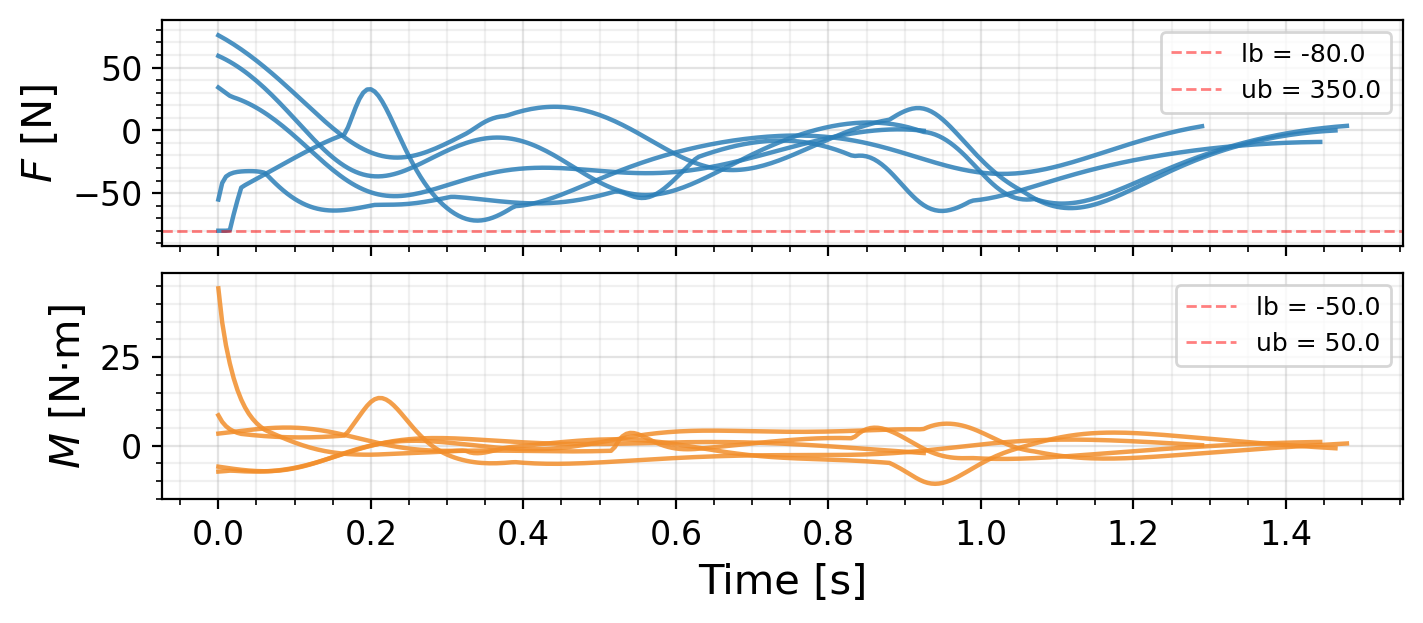

In [ ]:
# ── Control inputs F and M along MPC trajectories ────────────────────────────
px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    2, 1, figsize=(700 * px_fig, 300 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for tu in traj_u_mpc_filt:
    if len(tu) == 0:
        continue
    t = np.arange(len(tu)) * dt
    axes[0].plot(t, tu[:, 0], lw=1.6, alpha=0.85, color="#2C7FB8")  # thrust
    axes[1].plot(t, tu[:, 1], lw=1.6, alpha=0.85, color="#F28E2B")  # moment

u_all = np.vstack([tu for tu in traj_u_mpc_filt if len(tu) > 0])

for i, (ax, (lo, hi), lbl) in enumerate(
    zip(axes, [(F_lb, F_ub), (M_lb, M_ub)], ["$F$ [N]", "$M$ [N$\\cdot$m]"])
):
    # 上下界线（弱化显示）
    ax.axhline(lo, color="red", lw=1.0, ls="--", alpha=0.5, label=f"lb = {lo}")
    ax.axhline(hi, color="red", lw=1.0, ls="--", alpha=0.5, label=f"ub = {hi}")

    # 用全量数据范围设置 y 轴，并保留少量冗余，避免信号被截断
    d_min = float(np.min(u_all[:, i]))
    d_max = float(np.max(u_all[:, i]))
    span = max(d_max - d_min, 1e-6)
    pad = 0.08 * span
    ax.set_ylim(d_min - pad, d_max + pad)

    ax.set_ylabel(lbl, fontsize=15)
    ax.tick_params(labelsize=12)
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.18)
    ax.legend(fontsize=9, loc="upper right")


axes[1].set_xlabel("Time [s]", fontsize=15)
# fig.suptitle("Control inputs along closed-loop MPC trajectories", fontsize=13)
plt.show()

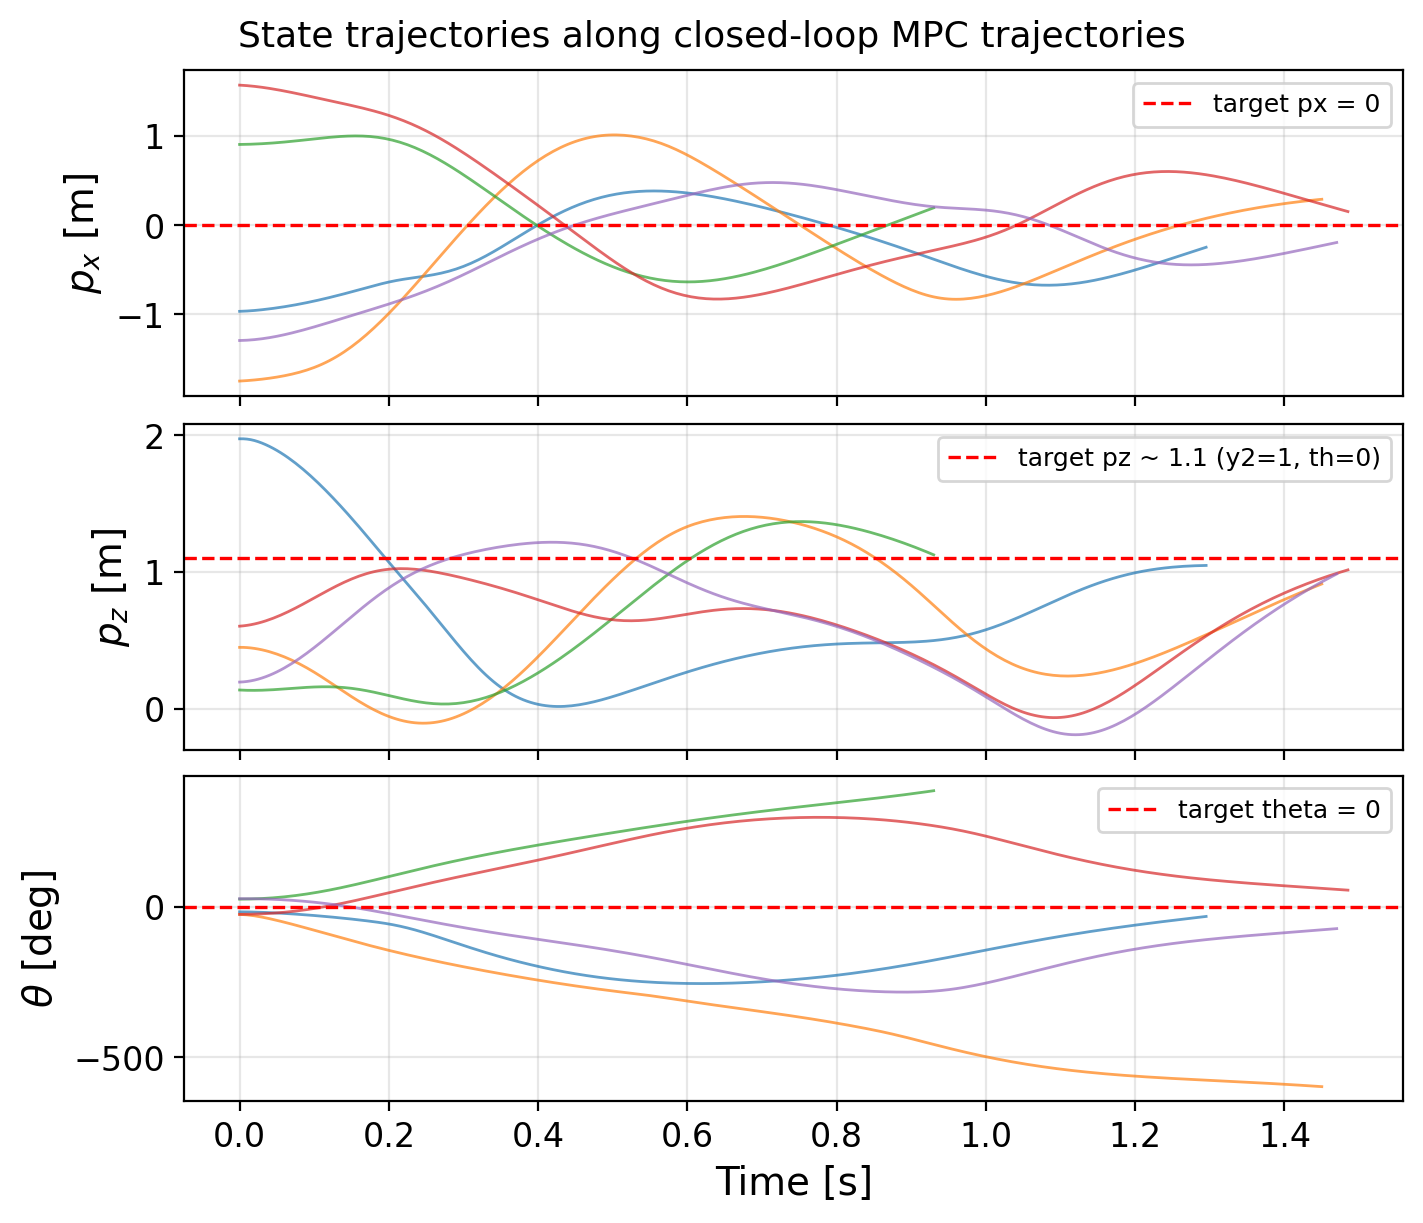

In [ ]:
# ── State trajectories: position and attitude ──────────────────────────────────
px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    3, 1, figsize=(700 * px_fig, 600 * px_fig), layout="constrained", sharex=True
)
fig.set_dpi(200)

for tx in traj_x_mpc_filt:
    t = np.arange(tx.shape[0]) * dt
    axes[0].plot(t, tx[:, 0], lw=1.0, alpha=0.7)  # px
    axes[1].plot(t, tx[:, 1], lw=1.0, alpha=0.7)  # pz
    axes[2].plot(t, np.degrees(tx[:, 2]), lw=1.0, alpha=0.7)  # theta [deg]

axes[0].axhline(0, color="red", lw=1.2, ls="--", label="target px = 0")
axes[1].axhline(
    1 + L, color="red", lw=1.2, ls="--", label=f"target pz ~ {1 + L:.1f} (y2=1, th=0)"
)
axes[2].axhline(0, color="red", lw=1.2, ls="--", label="target theta = 0")

labels = ["$p_x$ [m]", "$p_z$ [m]", "$\\theta$ [deg]"]
for ax, lbl in zip(axes, labels):
    ax.set_ylabel(lbl, fontsize=14)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time [s]", fontsize=14)
fig.suptitle("State trajectories along closed-loop MPC trajectories", fontsize=13)
plt.show()